<a href="https://colab.research.google.com/github/mirian2004/AI-AI-/blob/Day08/Day8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 데이터 준비
# 계산을 쉽게 확인하기 위해 x=2.0, 정답 y=6.0 (즉, 정답 w=3.0)으로 설정
X = torch.tensor([2.0])
y_true = torch.tensor([6.0])

print(f"입력: {X.item()}, 정답: {y_true.item()} (목표 w = 3.0)")

입력: 2.0, 정답: 6.0 (목표 w = 3.0)


In [2]:
# 2. 모델 초기화
model = nn.Linear(1,1,bias=False) # 편향 없이 w만 학습

# 가중치를 1.0으로 강제 설정
with torch.no_grad():
    model.weight.fill_(1.0)

print(f"초기 가중치(w): {model.weight.item():.1f}")

초기 가중치(w): 1.0


**단일 뉴런 신경망 구현**

Loss 함수는 Mean Squared Error(MSE) Loss를 사용

In [4]:
# 3. 학습 설정
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.05)

# 기록용 리스트
history_pytorch_grad = []
history_manual_grad = []
history_w = []

epochs = 20

In [5]:
# 4. 역전파 검증 실험 (Auto vs Manual)
print("\n 기울기 계산 검증 시작...\n")
print(f"{'Epoch':^5} | {'현재 w':^10} | {'Pytorch Grad':^15} | {'계산 Grad':^15}")
print("-"*65)

for epoch in range(epochs):
  # [Step 1] 순전파
  y_pred = model(X)
  loss = criterion(y_pred, y_true)

  # [Step 2] PyTorch 자동 미분 (Autograd)
  optimizer.zero_grad() # 이전 학습단계에서 계산된 기울기(순전파)를 초기화.
  loss.backward() # Pytorch 내부적으로 역전파를 실행해 계산해줌
  pytorch_grad = model.weight.grad.item()

  # [Step 3] 직접 미분 공식으로 계산
  # 공식: Gradient = 2 * (예측값 - 정답) * 입력값
  # (MSE 미분 : dL/dw = 2 * (w * x - y) * x )
  with torch.no_grad():
    manual_grad = 2*(y_pred - y_true) * X
    manual_grad = manual_grad.item()

  # [Step 4] 기록 및 출력
  history_pytorch_grad.append(pytorch_grad)
  history_manual_grad.append(manual_grad)
  history_w.append(model.weight.item())

  print(f"{epoch+1:^5} | {model.weight.item():^10.4f} | {pytorch_grad:^15.4f} | {manual_grad:^15.4f}")

  # [Step 5] 업데이트
  optimizer.step()


 기울기 계산 검증 시작...

Epoch |    현재 w    |  Pytorch Grad   |     계산 Grad    
-----------------------------------------------------------------
  1   |   1.0000   |    -16.0000     |    -16.0000    
  2   |   1.8000   |     -9.6000     |     -9.6000    
  3   |   2.2800   |     -5.7600     |     -5.7600    
  4   |   2.5680   |     -3.4560     |     -3.4560    
  5   |   2.7408   |     -2.0736     |     -2.0736    
  6   |   2.8445   |     -1.2442     |     -1.2442    
  7   |   2.9067   |     -0.7465     |     -0.7465    
  8   |   2.9440   |     -0.4479     |     -0.4479    
  9   |   2.9664   |     -0.2687     |     -0.2687    
 10   |   2.9798   |     -0.1612     |     -0.1612    
 11   |   2.9879   |     -0.0967     |     -0.0967    
 12   |   2.9927   |     -0.0580     |     -0.0580    
 13   |   2.9956   |     -0.0348     |     -0.0348    
 14   |   2.9974   |     -0.0209     |     -0.0209    
 15   |   2.9984   |     -0.0125     |     -0.0125    
 16   |   2.9991   |     -0.0075   

**역전파 기울기 계산 비교**

미분 공식으로 계산한 기울기와 역전파로 계산된 값 비교.

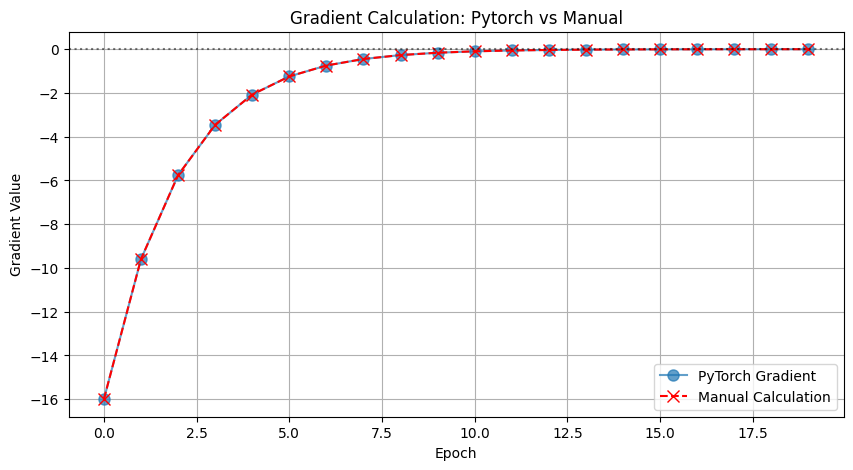


 최종 w: 2.9999 (목표값 3.0)


In [7]:
# 5. 기울기 비교 및 수렴 시각화

plt.figure(figsize=(10, 5))

# 기울기 크기 변화 (Gradient Magnitude)
plt.plot(history_pytorch_grad, 'o-', label='PyTorch Gradient', markersize=8, alpha=0.7)
plt.plot(history_manual_grad, 'x--', label='Manual Calculation', markersize=8, color='red')
plt.axhline(y=0, color='black', linestyle=':', alpha=0.5)

plt.title('Gradient Calculation: Pytorch vs Manual')
plt.xlabel('Epoch')
plt.ylabel('Gradient Value')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n 최종 w: {model.weight.item():.4f} (목표값 3.0)")

**기울기 비교 시각화**

미분 공식으로 계산한 기울기와 역전파로 계산된 값을 시각화하여 비교

**기울기 비교 및 수렵 시각화**

두 기울기가 동일하며 학습하루록 기울기가 0에 가까워져 학습이 수렴함

**그래프 형태 분석**

학습초기에는 기울기의 절대값이 매우 큼 > 현재 가중치와 목표 가중치의 차이가 매우 커 수정이 많이 필요하기 때문
학습이 진행될수록 기울기는 0에 가까워짐 > 가중치 목표값인 3에 가까워지며 더이상 수정할 필요가 없음을 의미함